In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import pickle

In [4]:
df = pd.read_csv("cardio_train.csv", sep=';')

In [5]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [9]:
df.drop("id", axis=1, inplace=True)

In [10]:
df['age'] = df['age'] / 365

In [11]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


In [12]:
#Exploratory Data Analysis (EDA)

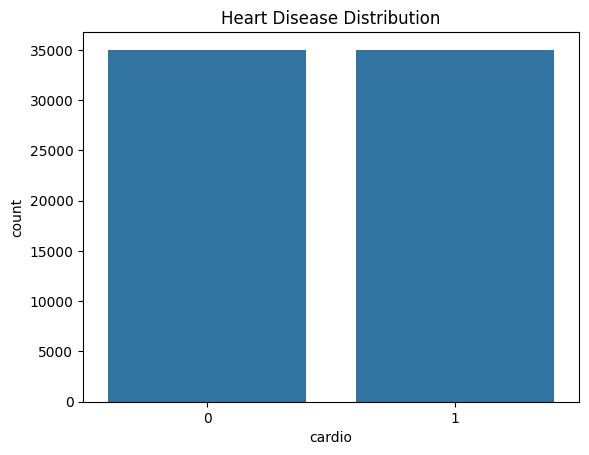

In [13]:
#Target Variable Distribution
sns.countplot(x='cardio', data=df)
plt.title("Heart Disease Distribution")
plt.show()

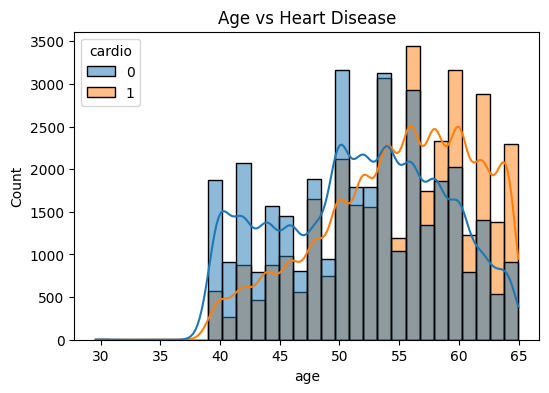

In [14]:
#Age vs Heart Diseaseplt.figure(figsize=(6,4))
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='age', hue='cardio', bins=30, kde=True)
plt.title("Age vs Heart Disease")
plt.show()

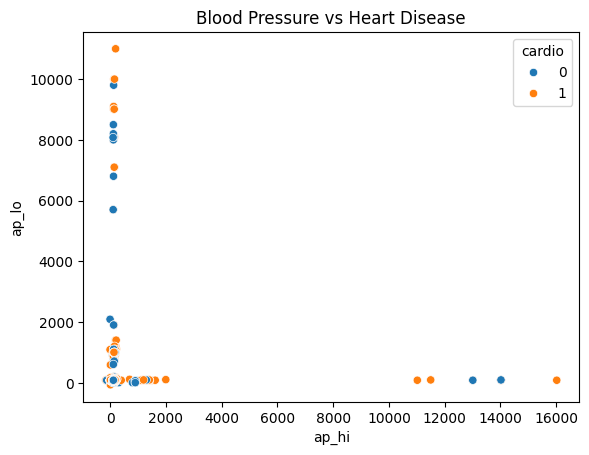

In [15]:
#Blood Pressure Analysis
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df)
plt.title("Blood Pressure vs Heart Disease")
plt.show()

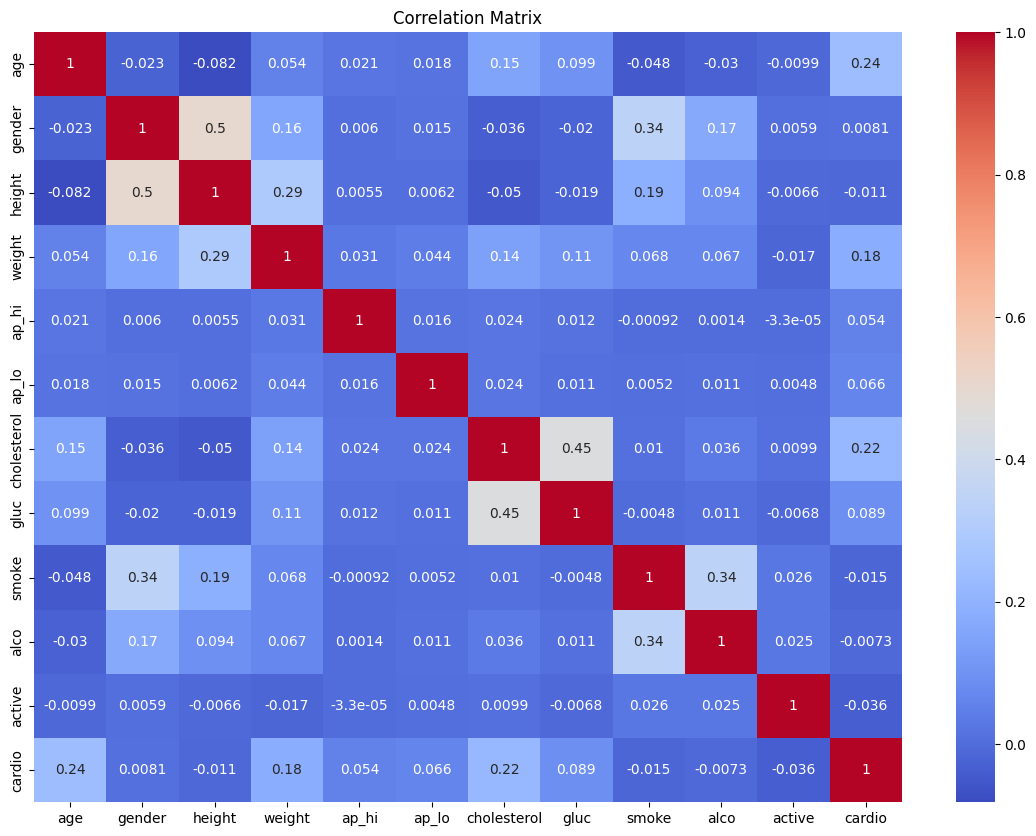

In [16]:
#Correlation Matrix
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [17]:
# Feature Selection & Scaling
X = df.drop("cardio", axis=1)
y = df["cardio"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [19]:
#Train & Compare ML Models

In [20]:
#Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

In [21]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))

In [23]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [29]:
#Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

In [32]:
#Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

svm_acc = accuracy_score(y_test, svm.predict(X_test))
svm_acc

0.7262857142857143

**Accuracy Comparison Table**




In [34]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "SVM", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_acc, knn_acc, svm_acc, dt_acc, rf_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.723643
1,KNN,0.648786
2,SVM,0.726286
3,Decision Tree,0.632000
4,Random Forest,0.716571


**Accuracy Bar Chart**

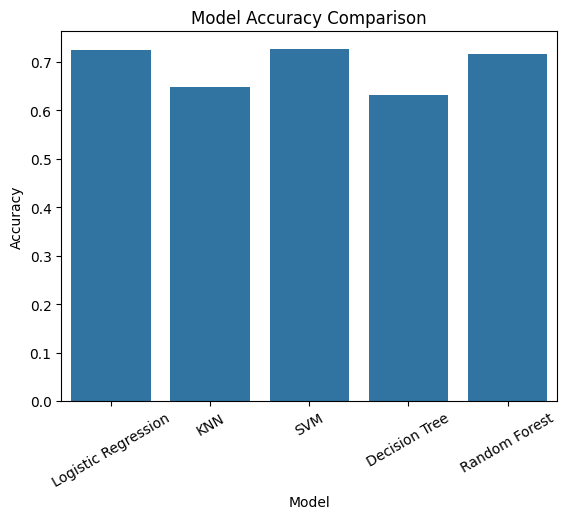

In [35]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()

In [39]:
import pickle

pickle.dump(svm, open("heart_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("features.pkl", "wb"))
